In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import joblib

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

(10000, 14)
Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0


In [4]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [5]:
df[['Geography', 'Gender']].nunique()

Geography    3
Gender       2
dtype: int64

In [6]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)
df['IsSenior'] = (df['Age'] > 50).astype(int)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,IsSenior
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000,0
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744670,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401362,0
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587035,0


In [7]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio,IsSenior,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744670,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401362,0,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,0.000000,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,1.587035,0,False,True,False


In [8]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X = X.astype(int)

print(X.shape)
print(y.shape)

(10000, 13)
(10000,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(8000, 13)
(2000, 13)


LogisticRegression

In [10]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1:", f1_score(y_test, lr_pred))
print("ROC AUC:", roc_auc_score(y_test, lr_prob))

Accuracy: 0.8095
Precision: 0.6
Recall: 0.19164619164619165
F1: 0.2905027932960894
ROC AUC: 0.7744786388854186


Decision Tree

In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_prob = dt.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1:", f1_score(y_test, dt_pred))
print("ROC AUC:", roc_auc_score(y_test, dt_prob))

Accuracy: 0.776
Precision: 0.45351473922902497
Recall: 0.4914004914004914
F1: 0.4716981132075472
ROC AUC: 0.670056805650026


RandomForest

In [12]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.8585
Precision: 0.7767857142857143
Recall: 0.4275184275184275
F1: 0.5515055467511886
ROC AUC: 0.8502470112639603


In [13]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8095,0.600000,0.191646,0.290503,0.774479
1,Decision Tree,0.7760,0.453515,0.491400,0.471698,0.670057
2,Random Forest,0.8585,0.776786,0.427518,0.551506,0.850247


Model Comparison

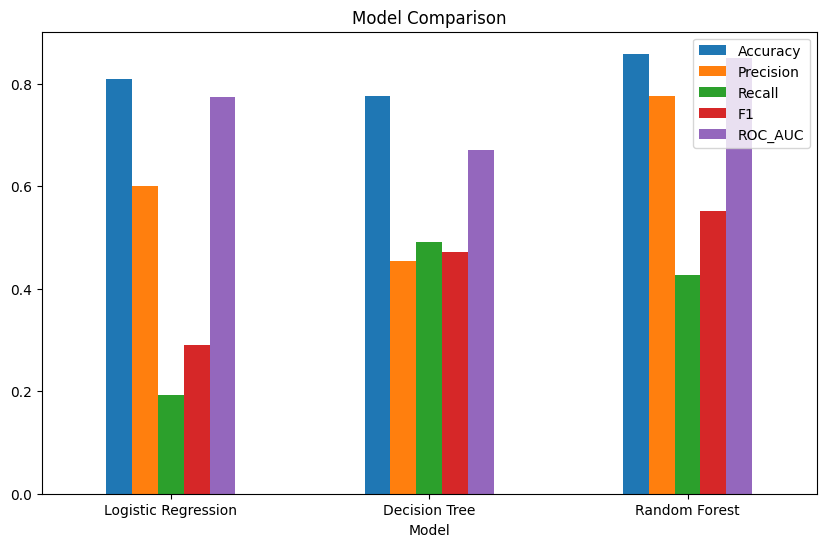

In [14]:
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']].plot(kind='bar', figsize=(10,6))
plt.title('Model Comparison')
plt.xticks(rotation=0)
plt.show()

ROC Curve Comparison

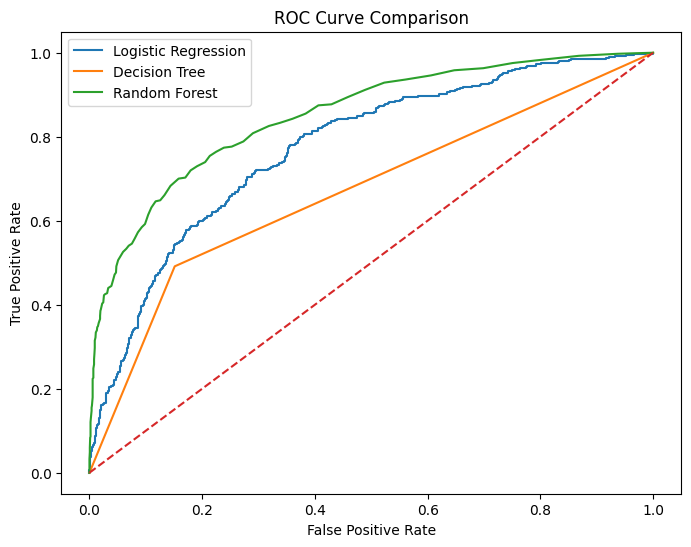

In [15]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8,6))
plt.plot(lr_fpr, lr_tpr, label='Logistic Regression')
plt.plot(dt_fpr, dt_tpr, label='Decision Tree')
plt.plot(rf_fpr, rf_tpr, label='Random Forest')
plt.plot([0,1], [0,1], '--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Confusion Matrix Comparison

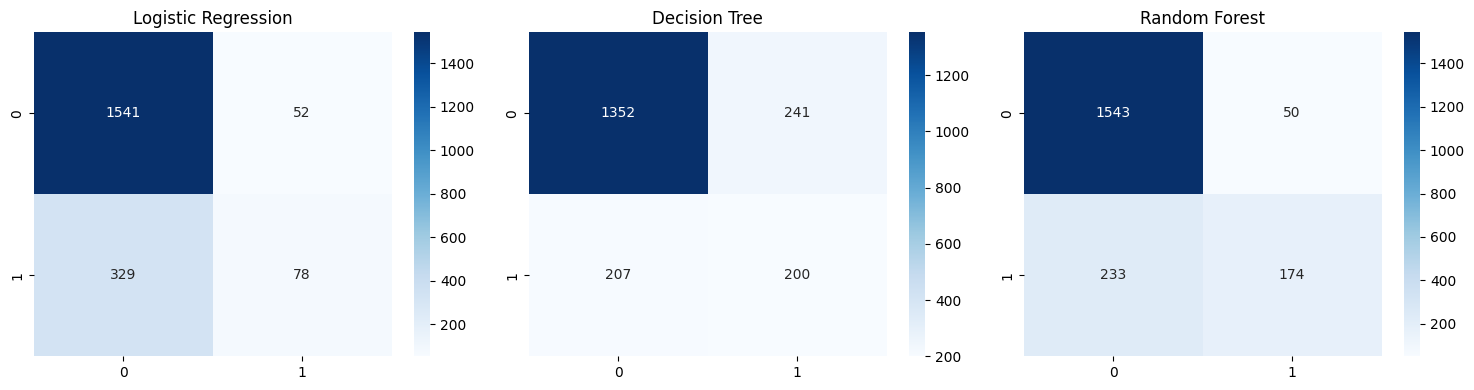

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')

sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Decision Tree')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Random Forest')

plt.tight_layout()
plt.show()

Feature Importance (RandomForest)

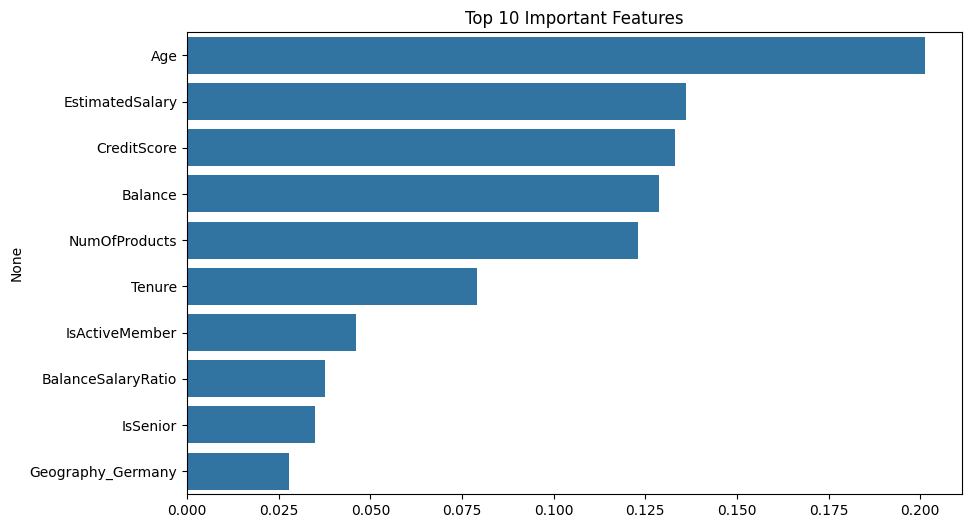

In [17]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importance.values[:10], y=importance.index[:10])
plt.title('Top 10 Important Features')
plt.show()

Saving the best model

In [18]:
best_model = rf
joblib.dump(best_model, 'best_model.pkl')

['best_model.pkl']

In [19]:
joblib.load('best_model.pkl')

RandomForestClassifier(random_state=42)

Testing the model prediction with random data

In [20]:
sample = pd.DataFrame([{
    'CreditScore': 650,
    'Age': 45,
    'Tenure': 5,
    'Balance': 120000,
    'NumOfProducts': 2,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 85000,
    'BalanceSalaryRatio': 120000 / 85001,
    'IsSenior': 0,
    'Geography_Germany': 0,
    'Geography_Spain': 1,
    'Gender_Male': 1
}])

prediction = best_model.predict(sample)
probability = best_model.predict_proba(sample)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 0
Probability: [[0.85 0.15]]


In [21]:
if prediction[0] == 1:
    print("Customer is likely to churn")
else:
    print("Customer is likely to stay")

Customer is likely to stay
